<a href="https://colab.research.google.com/github/minhmax098/Brain-Tumor-CNN/blob/main/Brain_Tumor_Classification_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_Project"
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Dataset folder:", DATASET_DIR)
print("Model folder:", MODEL_DIR)
print("Output folder:", OUTPUT_DIR)


Project folder: /content/drive/MyDrive/Brain_Tumor_Project
Dataset folder: /content/drive/MyDrive/Brain_Tumor_Project/dataset
Model folder: /content/drive/MyDrive/Brain_Tumor_Project/models
Output folder: /content/drive/MyDrive/Brain_Tumor_Project/outputs


In [3]:
INSTALL_AND_DOWNLOAD_DATASET = True

if INSTALL_AND_DOWNLOAD_DATASET:
    !pip install kagglehub -q
    import kagglehub
    import shutil

    source_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
    print("Downloaded dataset path:", source_path)

    if os.path.exists(DATASET_DIR):
        shutil.rmtree(DATASET_DIR)

    shutil.copytree(source_path, DATASET_DIR)
    print("Dataset copied to:", DATASET_DIR)
else:
    print("Skipping dataset download. Set INSTALL_AND_DOWNLOAD_DATASET = True if needed.")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Downloaded dataset path: /kaggle/input/brain-tumor-mri-dataset
Dataset copied to: /content/drive/MyDrive/Brain_Tumor_Project/dataset


In [4]:
import os

print("Dataset folder:", DATASET_DIR)
print("Items:", os.listdir(DATASET_DIR))

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

print("Training exists:", os.path.exists(TRAIN_DIR))
print("Testing exists:", os.path.exists(TEST_DIR))

if os.path.exists(TRAIN_DIR):
    print("Training classes:", os.listdir(TRAIN_DIR))

if os.path.exists(TEST_DIR):
    print("Testing classes:", os.listdir(TEST_DIR))
else:
    print("Testing folder is missing.")

Dataset folder: /content/drive/MyDrive/Brain_Tumor_Project/dataset
Items: ['Training', 'Testing']
Training exists: True
Testing exists: True
Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


**Count train/test image**

In [5]:
import pandas as pd

def count_images_by_class(folder):
    counts = {}

    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    return counts

train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

df_counts = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
}).fillna(0).astype(int)

print(df_counts)

print("\nTotal training images:", df_counts["Training"].sum())
print("Total testing images:", df_counts["Testing"].sum())
print("Total images:", df_counts.sum().sum())

            Training  Testing
glioma          1400      400
meningioma      1400      400
notumor         1400      400
pituitary       1400      400

Total training images: 5600
Total testing images: 1600
Total images: 7200


**Dataset distribution by class**

<Figure size 800x500 with 0 Axes>

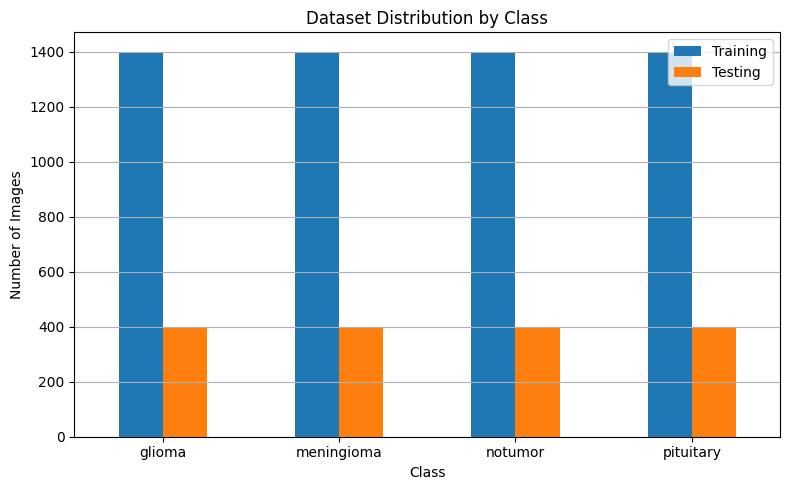

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/dataset_distribution.png


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Dataset Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "dataset_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Sample MRI Images from Each Class**

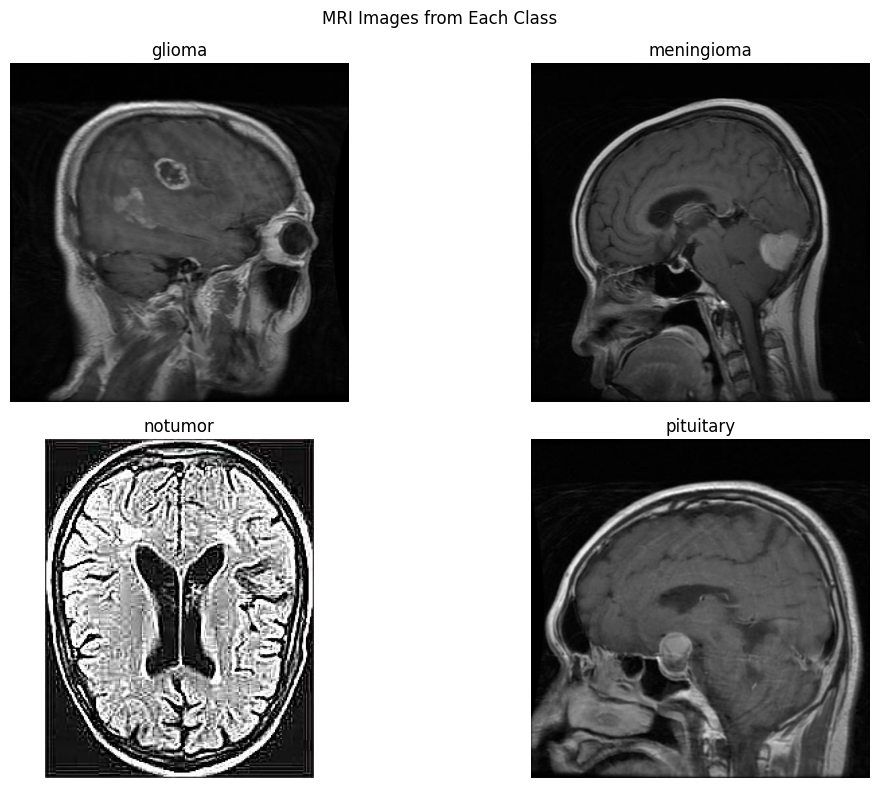

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/sample_mri_images.png


In [8]:
import random
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for idx, class_name in enumerate(sorted(os.listdir(TRAIN_DIR))):
    class_dir = os.path.join(TRAIN_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(class_dir, image_name)

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 2, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("MRI Images from Each Class")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "sample_mri_images.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Install library**

In [9]:
!pip install opencv-python scikit-learn matplotlib seaborn tqdm pandas -q

import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


**Check Dataset Structure**

In [10]:
print("Dataset root exists:", os.path.exists(DATASET_DIR))
print("Train folder exists:", os.path.exists(TRAIN_DIR))
print("Test folder exists:", os.path.exists(TEST_DIR))

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Dataset root exists: True
Train folder exists: True
Test folder exists: True
Train classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


**5. CLAHE Preprocessing and DataLoaders**

train_loader: used for CNN training and includes augmentation.

train_feature_loader: used for PCA-SVM feature extraction and does not include random augmentation.


In [11]:
def apply_clahe_pil(img):
    """Apply CLAHE to MRI image and return RGB PIL image."""
    img = np.array(img)

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = img.astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)

    return Image.fromarray(img_rgb)


IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_pil),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_pil),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Feature loaders for PCA-SVM: no augmentation and no shuffle
train_feature_dataset = datasets.ImageFolder(TRAIN_DIR, transform=test_transform)
test_feature_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_feature_loader = DataLoader(
    train_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Class to index:", train_dataset.class_to_idx)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Number of classes:", num_classes)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 5600
Testing samples: 1600
Number of classes: 4


**Dataset Visualization**

            Train  Test
glioma       1400   400
meningioma   1400   400
notumor      1400   400
pituitary    1400   400


<Figure size 800x500 with 0 Axes>

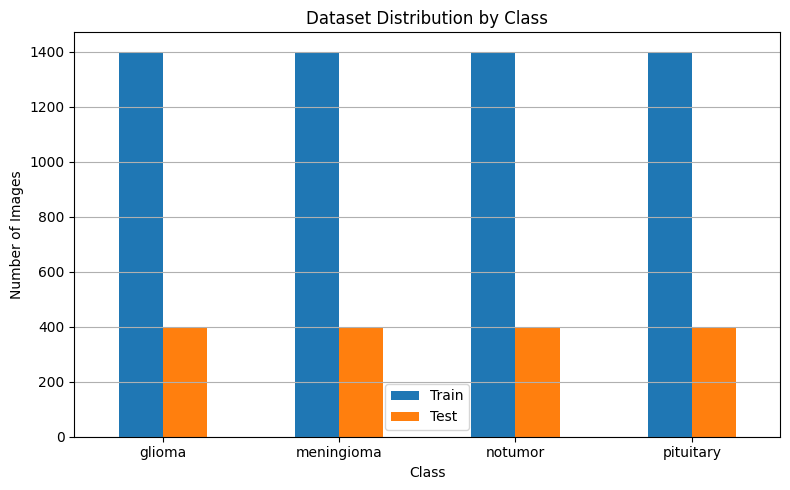

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/dataset_distribution.png


In [12]:
def count_images(folder_path):
    counts = {}
    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            valid_files = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
            ]
            counts[class_name] = len(valid_files)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
}).fillna(0).astype(int)

print(df_counts)

plt.figure(figsize=(8, 5))
df_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Dataset Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "dataset_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved to:", save_path)


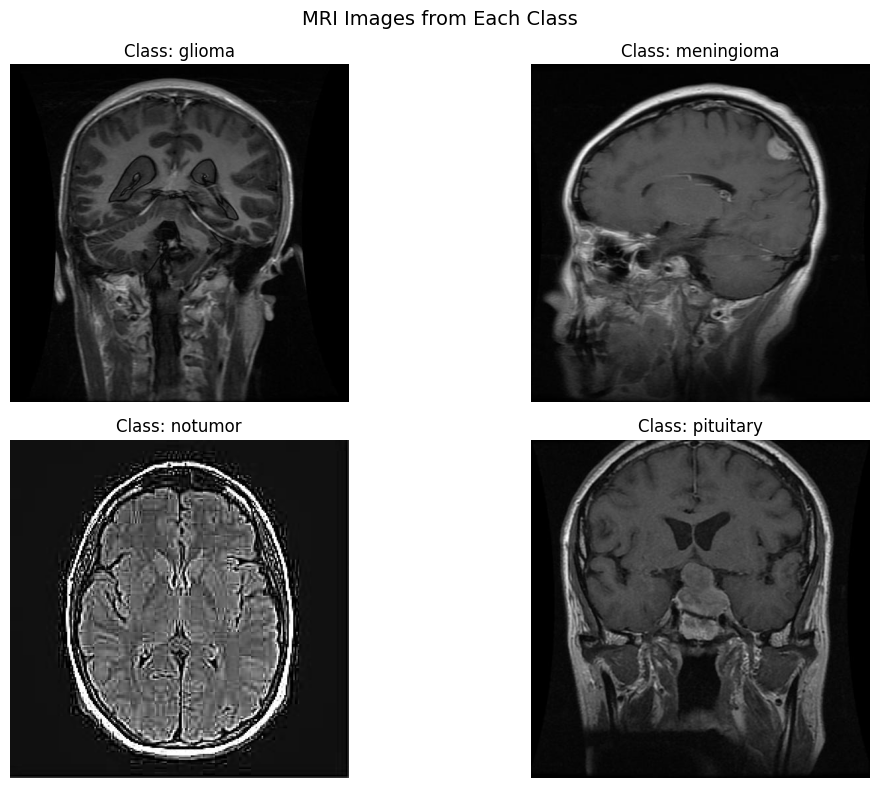

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/sample_mri_images.png


In [14]:
plt.figure(figsize=(12, 8))

for idx, class_name in enumerate(class_names, start=1):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]
    image_name = random.choice(image_files)
    image_path = os.path.join(class_dir, image_name)

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 2, idx)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")

plt.suptitle("MRI Images from Each Class", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "sample_mri_images.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved to:", save_path)


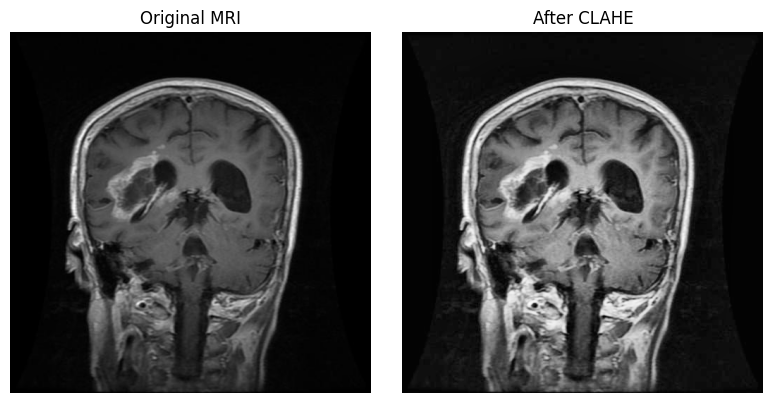

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/clahe_comparison.png


In [15]:
sample_class = class_names[0]
sample_dir = os.path.join(TRAIN_DIR, sample_class)
sample_files = [
    f for f in os.listdir(sample_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]
sample_path = os.path.join(sample_dir, random.choice(sample_files))

original_img = Image.open(sample_path).convert("RGB")
clahe_img = apply_clahe_pil(original_img)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_img)
plt.title("After CLAHE")
plt.axis("off")

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "clahe_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved to:", save_path)


**Common Training, Evaluation, Feature Extraction, and Plot Functions**

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, dataloader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )


def extract_features(model, dataloader):
    model.eval()

    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            outputs = model(images)

            features.append(outputs.cpu().numpy())
            labels_list.extend(labels.numpy())

    features = np.concatenate(features, axis=0)
    labels_list = np.array(labels_list)

    return features, labels_list


In [17]:
def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", save_path)


def save_roc_curve(y_true, y_prob, title, filename):
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} AUC = {roc_auc:.3f}")

    macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} (Macro AUC = {macro_auc:.3f})")
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Macro AUC:", macro_auc)
    print("Saved to:", save_path)
    return macro_auc


def save_training_curves(train_losses, test_losses, train_accs, test_accs, prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss - {prefix}")
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(OUTPUT_DIR, f"{prefix}_loss.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", save_path)

    plt.figure(figsize=(8, 5))
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(test_accs, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training and Validation Accuracy - {prefix}")
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(OUTPUT_DIR, f"{prefix}_accuracy.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", save_path)


def save_classification_report(y_true, y_pred, model_name, filename):
    report_text = classification_report(y_true, y_pred, target_names=class_names)
    print(report_text)

    save_path = os.path.join(OUTPUT_DIR, filename)
    with open(save_path, "w") as f:
        f.write(f"Classification Report - {model_name}\n\n")
        f.write(report_text)

    print("Saved to:", save_path)


**MobileNetV2: Transfer Learning and Fine-Tuning**

In [18]:
def build_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)


mobilenet = build_mobilenetv2(num_classes)
criterion = nn.CrossEntropyLoss()

print("MobileNetV2 ready.")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 84.6MB/s]


MobileNetV2 ready.


**MobileNetV2 Stage 1 Transfer Learning**

In [19]:
# Stage 1: train classifier head only
EPOCHS_MOBILE_STAGE1 = 10

mobilenet_train_losses = []
mobilenet_test_losses = []
mobilenet_train_accs = []
mobilenet_test_accs = []

best_mobilenet_acc = 0.0

optimizer_mobilenet = optim.Adam(mobilenet.classifier.parameters(), lr=1e-4)
scheduler_mobilenet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobilenet, mode="min", factor=0.2, patience=2
)

for epoch in range(EPOCHS_MOBILE_STAGE1):
    print(f"\nMobileNetV2 Stage 1 Epoch {epoch + 1}/{EPOCHS_MOBILE_STAGE1}")

    train_loss, train_acc = train_one_epoch(mobilenet, train_loader, criterion, optimizer_mobilenet)
    test_loss, test_acc, mobile_y_true, mobile_y_pred, mobile_y_prob = evaluate(mobilenet, test_loader, criterion)

    scheduler_mobilenet.step(test_loss)

    mobilenet_train_losses.append(train_loss)
    mobilenet_test_losses.append(test_loss)
    mobilenet_train_accs.append(train_acc)
    mobilenet_test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > best_mobilenet_acc:
        best_mobilenet_acc = test_acc
        torch.save(mobilenet.state_dict(), os.path.join(MODEL_DIR, "best_mobilenetv2_stage1.pth"))
        print("Saved best MobileNetV2 stage1 model.")



MobileNetV2 Stage 1 Epoch 1/10


100%|██████████| 50/50 [00:32<00:00,  1.54it/s]


Train Loss: 0.9583 | Train Acc: 0.6663
Test Loss: 0.7221 | Test Acc: 0.7588
Saved best MobileNetV2 stage1 model.

MobileNetV2 Stage 1 Epoch 2/10


100%|██████████| 50/50 [00:19<00:00,  2.63it/s]


Train Loss: 0.5676 | Train Acc: 0.8073
Test Loss: 0.6433 | Test Acc: 0.7631
Saved best MobileNetV2 stage1 model.

MobileNetV2 Stage 1 Epoch 3/10


...

Train Loss: 0.3892 | Train Acc: 0.8580
Test Loss: 0.5490 | Test Acc: 0.8156
Saved best MobileNetV2 stage1 model.

MobileNetV2 Stage 1 Epoch 9/10


100%|██████████| 50/50 [00:14<00:00,  3.44it/s]


Train Loss: 0.3854 | Train Acc: 0.8580
Test Loss: 0.5515 | Test Acc: 0.8125

MobileNetV2 Stage 1 Epoch 10/10


100%|██████████| 50/50 [00:14<00:00,  3.39it/s]


Train Loss: 0.3681 | Train Acc: 0.8673
Test Loss: 0.5413 | Test Acc: 0.8169
Saved best MobileNetV2 stage1 model.


**MobileNetV2 Stage 2 Fine-tuning**

In [20]:
# Stage 2: fine-tune last MobileNetV2 layers
for param in mobilenet.features[-4:].parameters():
    param.requires_grad = True

optimizer_mobilenet = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=1e-5
)

scheduler_mobilenet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobilenet, mode="min", factor=0.2, patience=2
)

EPOCHS_MOBILE_STAGE2 = 30
best_mobilenet_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS_MOBILE_STAGE2):
    print(f"\nMobileNetV2 Fine-tuning Epoch {epoch + 1}/{EPOCHS_MOBILE_STAGE2}")

    train_loss, train_acc = train_one_epoch(mobilenet, train_loader, criterion, optimizer_mobilenet)
    test_loss, test_acc, mobile_y_true, mobile_y_pred, mobile_y_prob = evaluate(mobilenet, test_loader, criterion)

    scheduler_mobilenet.step(test_loss)

    mobilenet_train_losses.append(train_loss)
    mobilenet_test_losses.append(test_loss)
    mobilenet_train_accs.append(train_acc)
    mobilenet_test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > best_mobilenet_acc:
        best_mobilenet_acc = test_acc
        torch.save(mobilenet.state_dict(), os.path.join(MODEL_DIR, "best_mobilenetv2_finetuned_acc.pth"))
        print("Saved best MobileNetV2 accuracy model.")

    if test_loss < best_mobilenet_val_loss:
        best_mobilenet_val_loss = test_loss
        counter = 0
        torch.save(mobilenet.state_dict(), os.path.join(MODEL_DIR, "best_mobilenetv2_finetuned_loss.pth"))
        print("Saved best MobileNetV2 loss model.")
    else:
        counter += 1
        print(f"EarlyStopping Counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break



MobileNetV2 Fine-tuning Epoch 1/30


100%|██████████| 50/50 [00:15<00:00,  3.24it/s]


Train Loss: 0.3485 | Train Acc: 0.8727
Test Loss: 0.5361 | Test Acc: 0.8394
Saved best MobileNetV2 accuracy model.
Saved best MobileNetV2 loss model.

MobileNetV2 Fine-tuning Epoch 2/30


100%|██████████| 50/50 [00:15<00:00,  3.16it/s]


Train Loss: 0.2949 | Train Acc: 0.8986
Test Loss: 0.4973 | Test Acc: 0.8506
Saved best MobileNetV2 accuracy model.
Saved best MobileNetV2 loss model.

MobileNetV2 Fine-tuning Epoch 3/30


...

Train Loss: 0.1507 | Train Acc: 0.9466
Test Loss: 0.4203 | Test Acc: 0.8869
EarlyStopping Counter: 3/5

MobileNetV2 Fine-tuning Epoch 19/30


100%|██████████| 50/50 [00:15<00:00,  3.18it/s]


Train Loss: 0.1497 | Train Acc: 0.9491
Test Loss: 0.4093 | Test Acc: 0.8875
EarlyStopping Counter: 4/5

MobileNetV2 Fine-tuning Epoch 20/30


100%|██████████| 50/50 [00:15<00:00,  3.27it/s]

Train Loss: 0.1488 | Train Acc: 0.9491
Test Loss: 0.4297 | Test Acc: 0.8838
EarlyStopping Counter: 5/5
Early stopping triggered.


**MobileNetV2 Evaluation**

In [21]:
best_mobilenet_path = os.path.join(MODEL_DIR, "best_mobilenetv2_finetuned_acc.pth")

mobilenet.load_state_dict(torch.load(best_mobilenet_path, map_location=device))
mobilenet.eval()

mobile_test_loss, mobile_test_acc, mobile_y_true, mobile_y_pred, mobile_y_prob = evaluate(
    mobilenet, test_loader, criterion
)

mobilenet_acc = accuracy_score(mobile_y_true, mobile_y_pred)
print("Final MobileNetV2 Test Accuracy:", mobilenet_acc)


100%|██████████| 50/50 [00:25<00:00,  1.94it/s]

Final MobileNetV2 Test Accuracy: 0.88875


              precision    recall  f1-score   support

      glioma       0.97      0.71      0.82       400
  meningioma       0.82      0.86      0.84       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/classification_report_mobilenetv2.txt


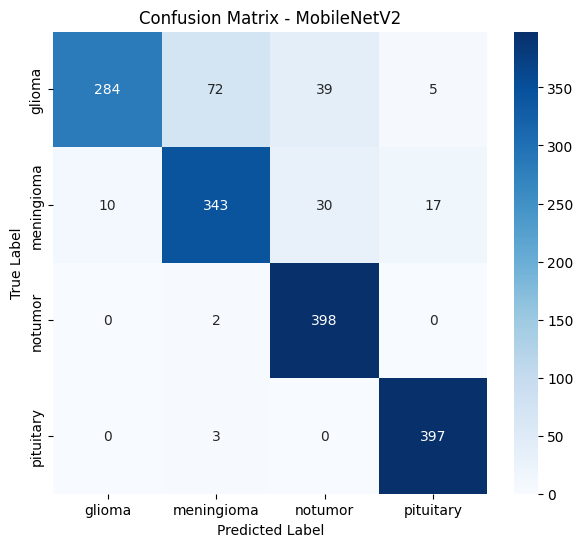

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/confusion_matrix_mobilenetv2.png


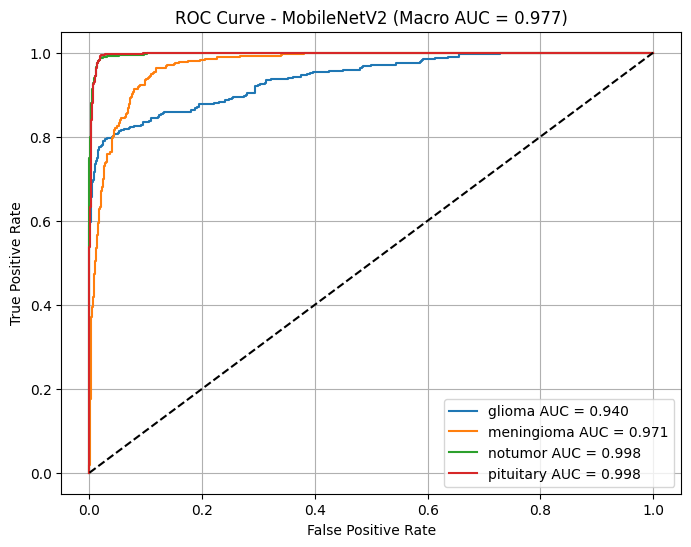

Macro AUC: 0.976896875
Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/roc_curve_mobilenetv2.png


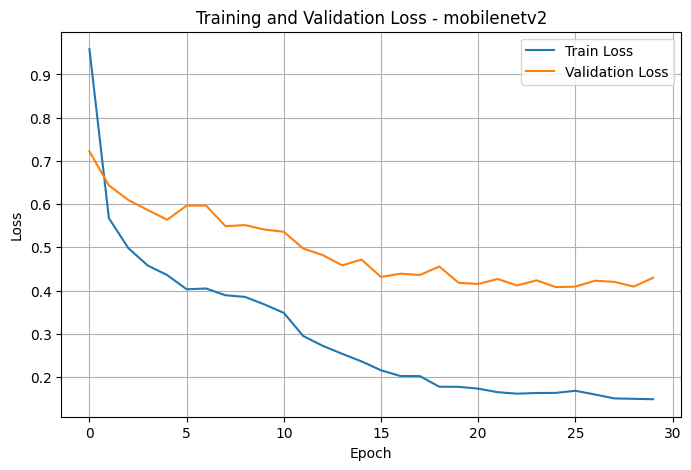

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/mobilenetv2_loss.png


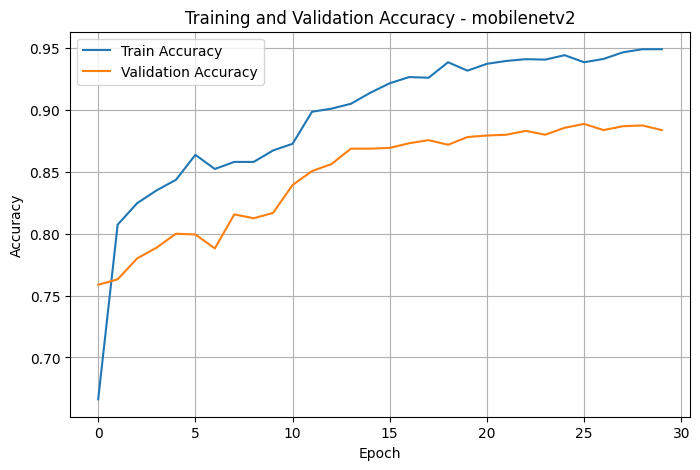

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/mobilenetv2_accuracy.png


In [22]:
save_classification_report(
    mobile_y_true,
    mobile_y_pred,
    "MobileNetV2",
    "classification_report_mobilenetv2.txt"
)

save_confusion_matrix(
    mobile_y_true,
    mobile_y_pred,
    "Confusion Matrix - MobileNetV2",
    "confusion_matrix_mobilenetv2.png"
)

mobilenet_auc = save_roc_curve(
    mobile_y_true,
    mobile_y_prob,
    "ROC Curve - MobileNetV2",
    "roc_curve_mobilenetv2.png"
)

save_training_curves(
    mobilenet_train_losses,
    mobilenet_test_losses,
    mobilenet_train_accs,
    mobilenet_test_accs,
    "mobilenetv2"
)


MobileNetV2 + PCA-SVM Hybrid

This section uses **non-augmented feature loaders** for fair PCA-SVM feature extraction.

In [23]:
mobilenet_feature_extractor = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

mobilenet_feature_extractor.classifier = nn.Identity()
mobilenet_feature_extractor.features.load_state_dict(mobilenet.features.state_dict())
mobilenet_feature_extractor = mobilenet_feature_extractor.to(device)
mobilenet_feature_extractor.eval()

print("MobileNetV2 feature extractor ready.")

MobileNetV2 feature extractor ready.


In [24]:
X_train_mobile, y_train_mobile = extract_features(
    mobilenet_feature_extractor,
    train_feature_loader
)

X_test_mobile, y_test_mobile = extract_features(
    mobilenet_feature_extractor,
    test_feature_loader
)

print("MobileNetV2 train features:", X_train_mobile.shape)
print("MobileNetV2 test features:", X_test_mobile.shape)

100%|██████████| 50/50 [00:15<00:00,  3.30it/s]

MobileNetV2 train features: (5600, 1280)
MobileNetV2 test features: (1600, 1280)


In [25]:
mobilenet_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=SEED)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=SEED))
])

mobilenet_pca_svm.fit(X_train_mobile, y_train_mobile)

mobile_svm_pred = mobilenet_pca_svm.predict(X_test_mobile)
mobile_svm_prob = mobilenet_pca_svm.predict_proba(X_test_mobile)

mobilenet_pca_svm_acc = accuracy_score(y_test_mobile, mobile_svm_pred)

print("MobileNetV2 + PCA-SVM Accuracy:", mobilenet_pca_svm_acc)
print(classification_report(y_test_mobile, mobile_svm_pred, target_names=class_names))

MobileNetV2 + PCA-SVM Accuracy: 0.920625
              precision    recall  f1-score   support

      glioma       0.98      0.74      0.85       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



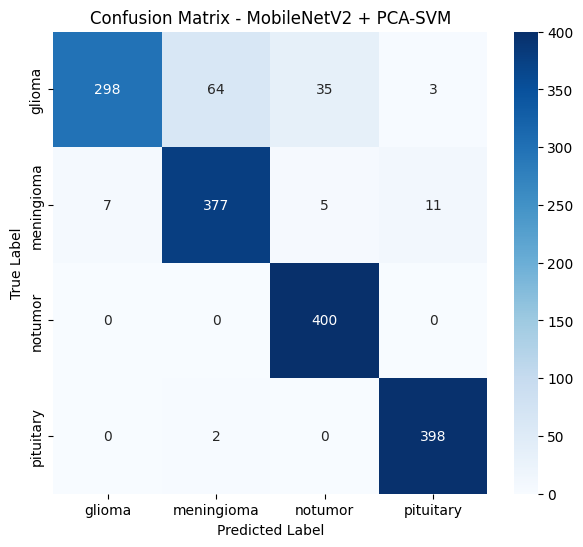

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/confusion_matrix_mobilenetv2_pca_svm.png


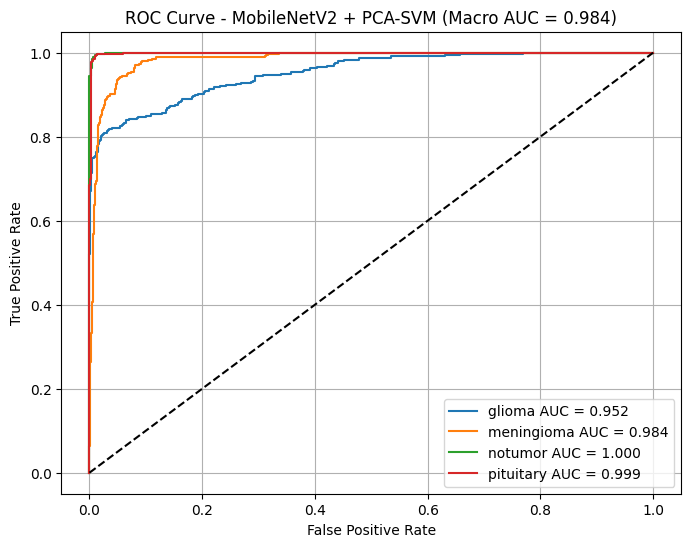

Macro AUC: 0.9837479166666667
Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/roc_curve_mobilenetv2_pca_svm.png


In [26]:
save_confusion_matrix(
    y_test_mobile,
    mobile_svm_pred,
    "Confusion Matrix - MobileNetV2 + PCA-SVM",
    "confusion_matrix_mobilenetv2_pca_svm.png"
)

mobilenet_pca_svm_auc = save_roc_curve(
    y_test_mobile,
    mobile_svm_prob,
    "ROC Curve - MobileNetV2 + PCA-SVM",
    "roc_curve_mobilenetv2_pca_svm.png"
)